In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# Load student performance data (Mathematics)

url = 'data/raw/student-mat.csv'
#sep -> means separator. It tells pandas what character separates the columns in the CSV file.
student_data = pd.read_csv(url, sep=';')

print(f"Dataset shape: {student_data.shape}")
student_data.head()

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [5]:
print("Dataset Info:")
print(student_data.info())
print("\nMissing Values:")
print(student_data.isnull().sum().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    s

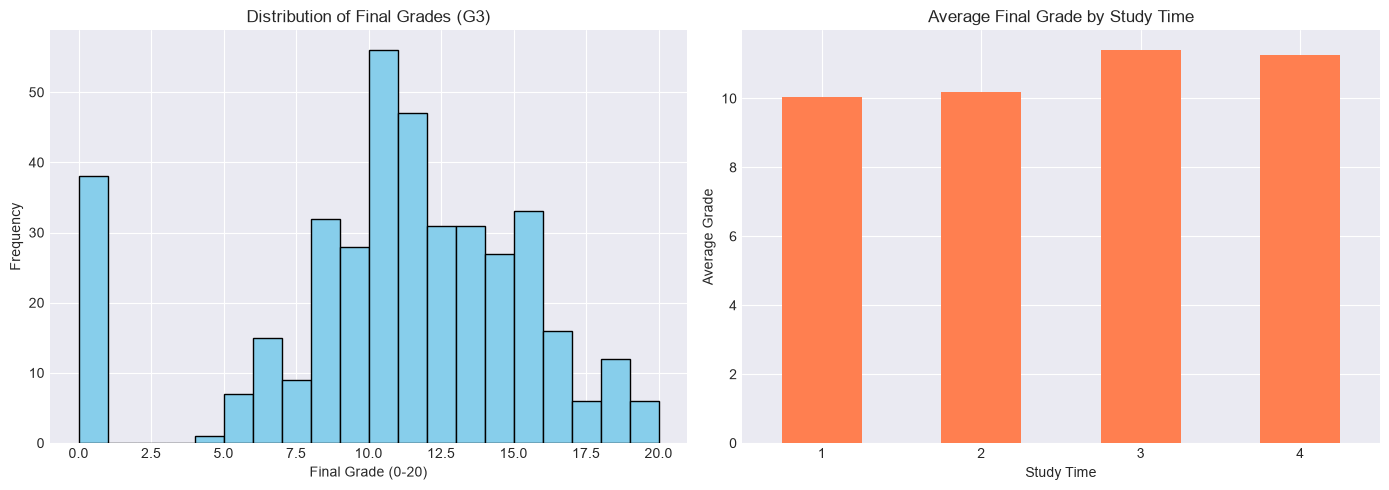

In [6]:
# Visualize final grade distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(student_data['G3'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Final Grades (G3)')
axes[0].set_xlabel('Final Grade (0-20)')
axes[0].set_ylabel('Frequency')

#Group the students according to their studytime
#After grouping students by study time, I only want to look at their final grades
#For each study-time group, calculate the average final grade.
student_data.groupby('studytime')['G3'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Final Grade by Study Time')
axes[1].set_xlabel('Study Time')
axes[1].set_ylabel('Average Grade')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()

In [7]:
# Prepare features for regression
# Select numerical and some categorical features
features_lr = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
               'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
target_lr = 'G3'

X_lr = student_data[features_lr]
y_lr = student_data[target_lr]

print(f"Features shape: {X_lr.shape}")
print(f"Target shape: {y_lr.shape}")

Features shape: (395, 15)
Target shape: (395,)


In [8]:
# Split data
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

# Scale features
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

print(f"Training set size: {X_train_lr.shape[0]}")
print(f"Test set size: {X_test_lr.shape[0]}")

Training set size: 316
Test set size: 79


In [9]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_lr_scaled, y_train_lr)

# Predictions
y_pred_train_lr = lr_model.predict(X_train_lr_scaled)
y_pred_test_lr = lr_model.predict(X_test_lr_scaled)

# Evaluate
train_r2 = r2_score(y_train_lr, y_pred_train_lr)
test_r2 = r2_score(y_test_lr, y_pred_test_lr)
test_rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_test_lr))
test_mae = mean_absolute_error(y_test_lr, y_pred_test_lr)

print("Linear Regression Performance:")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")

Linear Regression Performance:
Training R²: 0.8486
Test R²: 0.7804
Test RMSE: 2.12
Test MAE: 1.35


In [ ]:
# Feature importance
coefficients = pd.DataFrame({
    'Feature': features_lr,
    'Coefficient': lr_model.coef_
    #Before sorting, use the absolute value of the coefficients.
}).sort_values('Coefficient', key=abs, ascending=False)
display(coefficients)

,Feature,Coefficient
14,G2,3.665736
13,G1,0.516278
12,absences,0.377251
5,failures,-0.305709
6,famrel,0.295818
0,age,-0.251119
2,Fedu,-0.202797
8,goout,0.153833
1,Medu,0.101604
9,Dalc,-0.094702


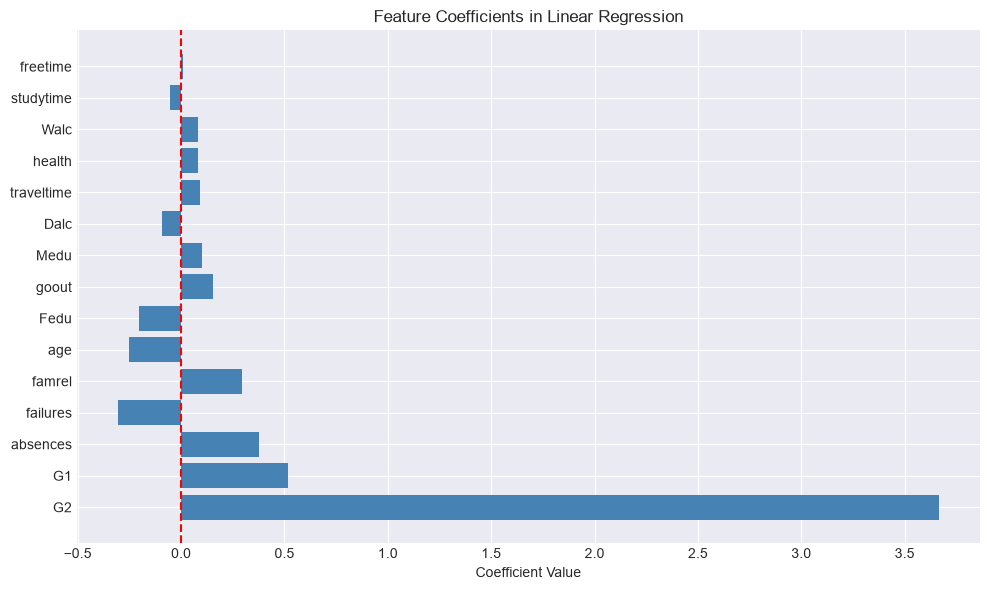

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients in Linear Regression')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()

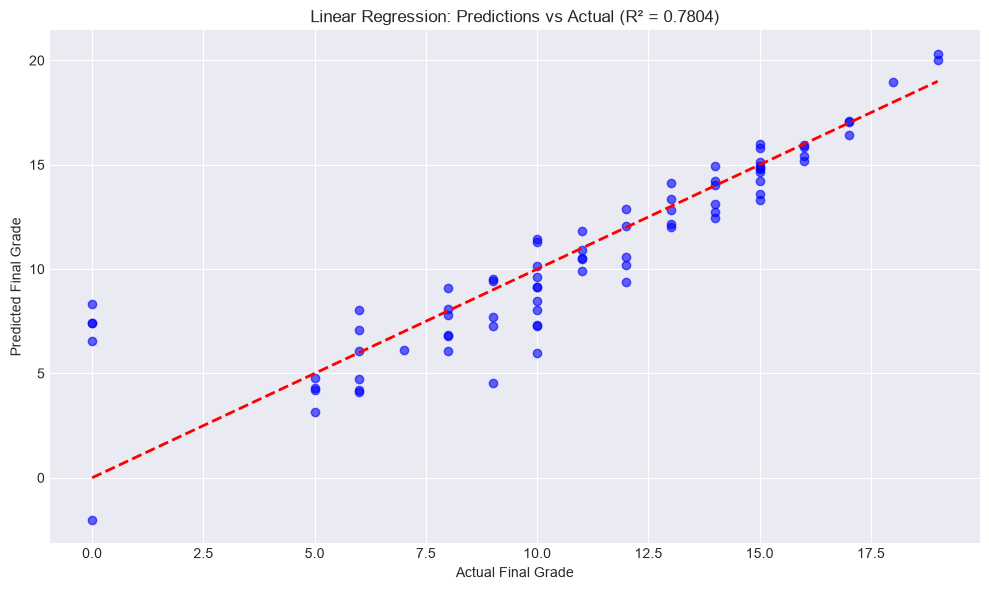

In [14]:
# Prediction vs Actual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lr, y_pred_test_lr, alpha=0.6, color='blue')
plt.plot([y_test_lr.min(), y_test_lr.max()], 
         [y_test_lr.min(), y_test_lr.max()], 'r--', lw=2)
plt.xlabel('Actual Final Grade')
plt.ylabel('Predicted Final Grade')
plt.title(f'Linear Regression: Predictions vs Actual (R² = {test_r2:.4f})')
plt.tight_layout()

In [23]:
# Logistic Regression
student_data['pass']=(student_data['G3']>=10).astype('int16')

print("pass/fail distribution:")
print(student_data['pass'].value_counts())
print(f"\nPass rate :  {student_data['pass'].mean()*100:.2f}%")

pass/fail distribution:
pass
1    265
0    130
Name: count, dtype: int64

Pass rate :  67.09%


In [24]:
#Prepare data for logistic regression
features_log = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

X_log = student_data[features_log]
y_log = student_data['pass']

# Split data
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

# Scale features
scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

In [25]:
# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_log_scaled, y_train_log)

# Predictions
y_pred_log = log_model.predict(X_test_log_scaled)
y_pred_proba = log_model.predict_proba(X_test_log_scaled)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log)
recall = recall_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Logistic Regression Performance:
Accuracy: 0.8861
Precision: 0.9783
Recall: 0.8491
F1-Score: 0.9091


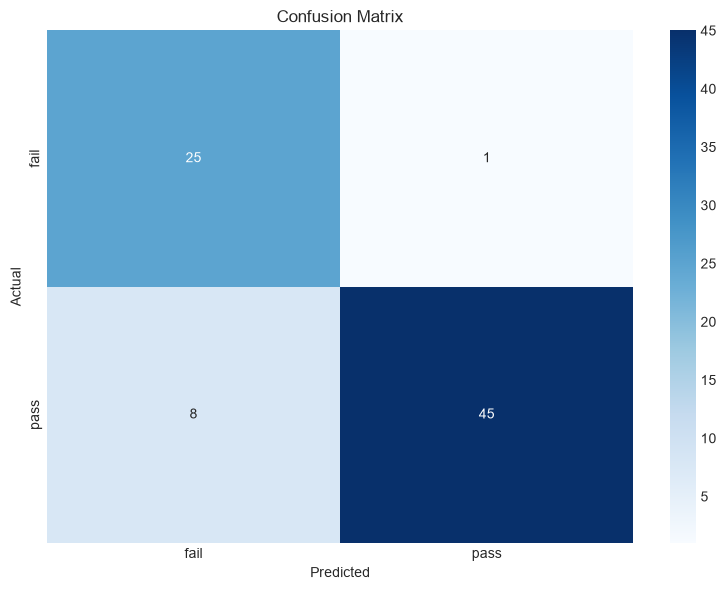


Classification Report:
              precision    recall  f1-score   support

        Fail       0.76      0.96      0.85        26
        Pass       0.98      0.85      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.91      0.88        79
weighted avg       0.91      0.89      0.89        79



In [35]:
# confusion matrix
cm=confusion_matrix(y_test_log,y_pred_log)
# display(cm)


plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['fail','pass'],
            yticklabels=['fail','pass'])

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log, 
                          target_names=['Fail', 'Pass']))

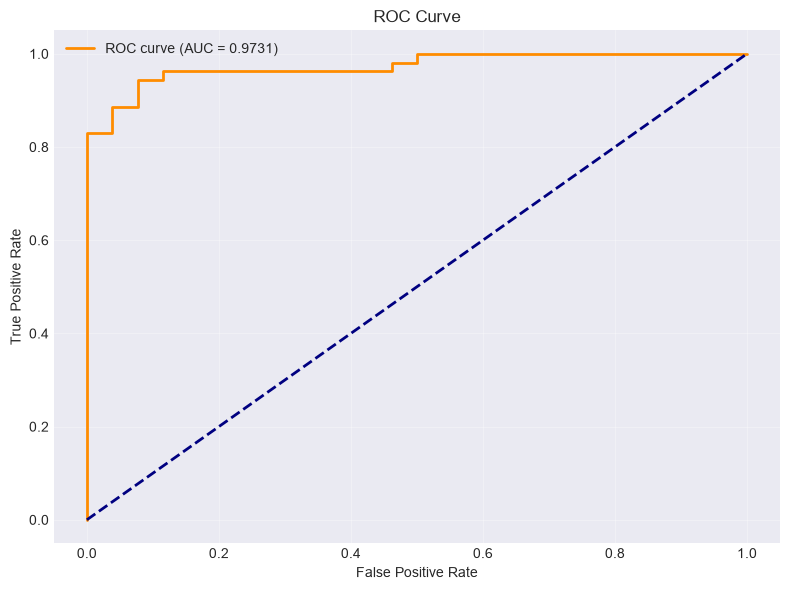

In [36]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test_log, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()